# 06 — Tracking básico con ByteTrack

Este notebook valida el Milestone 2 del proyecto Echomain.

Objetivo:
- Leer un video desde `data/raw/`.
- Segmentar robots y balón con SAM 3 usando los prompts definidos en M1.
- Asignar IDs persistentes con ByteTrack.
- Guardar trayectorias en CSV.
- Generar evidencia visual ligera para `docs/assets/m2/`.

Este notebook procesa pocos frames para que sea fácil de revisar.

Imports y rutas

In [1]:
from pathlib import Path
import sys
import cv2
import pandas as pd
import matplotlib.pyplot as plt

# Detectar raíz del proyecto aunque el notebook se ejecute desde /notebooks
ROOT = Path.cwd()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.video_utils import get_video_info, iter_video_frames
from src.segmentation import load_sam3_text_predictor, segment_frame_with_prompts
from src.tracking import FutbotTracker
from src.visualization import draw_tracking_frame
from src.export import init_tracks_csv, append_tracks_to_csv

VIDEO_PATH = ROOT / "data" / "raw" / "video-1080_singular_display.mov"
MODEL_PATH = ROOT / "assets" / "sam3.pt"

OUTPUT_CSV = ROOT / "outputs" / "metrics" / "tracks_notebook06.csv"

TRACKING_IMG = ROOT / "docs" / "assets" / "m2" / "tracking" / "tracking_sample.jpg"
TRAILS_IMG = ROOT / "docs" / "assets" / "m2" / "trails" / "trails_sample.jpg"
SAMPLE_CSV = ROOT / "docs" / "assets" / "m2" / "sample_tracks.csv"

TRACKING_IMG.parent.mkdir(parents=True, exist_ok=True)
TRAILS_IMG.parent.mkdir(parents=True, exist_ok=True)
SAMPLE_CSV.parent.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("VIDEO_PATH:", VIDEO_PATH)
print("MODEL_PATH:", MODEL_PATH)

ROOT: c:\Users\diego\OneDrive\Documentos\GitHub\Proyecto-VisionPorComputadora
VIDEO_PATH: c:\Users\diego\OneDrive\Documentos\GitHub\Proyecto-VisionPorComputadora\data\raw\video-1080_singular_display.mov
MODEL_PATH: c:\Users\diego\OneDrive\Documentos\GitHub\Proyecto-VisionPorComputadora\assets\sam3.pt


Verificacion de archivos

In [2]:
#Verificacion de Archivos
if not VIDEO_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró el video en {VIDEO_PATH}. "
        "Coloca el video oficial en data/raw/ con ese nombre."
    )

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró sam3.pt en {MODEL_PATH}. "
        "Descarga el modelo y colócalo en assets/sam3.pt."
    )

print("Archivos encontrados correctamente.")

Archivos encontrados correctamente.


Informacion de video

In [3]:
info = get_video_info(VIDEO_PATH)
info

{'width': 1360, 'height': 1808, 'fps': 59.70253473919419, 'total_frames': 1425}

Cargar SAM3 y ByteTrack

In [4]:
# Nota: cargar SAM 3 puede tardar, especialmente en CPU.
predictor = load_sam3_text_predictor(
    model_path=str(MODEL_PATH),
    conf=0.25,
)

tracker = FutbotTracker()

print("Predictor SAM 3 listo.")
print("Tracker listo.")

Usando ByteTrackTracker desde paquete trackers
Predictor SAM 3 listo.
Tracker listo.


Procesar pocos frames

In [5]:
MAX_FRAMES = 20
STRIDE = 1

init_tracks_csv(OUTPUT_CSV)

first_annotated_frame = None
last_annotated_frame = None
processed_frames = 0

for frame_idx, frame in iter_video_frames(
    VIDEO_PATH,
    max_frames=MAX_FRAMES,
    stride=STRIDE,
):
    print(f"Procesando frame {frame_idx}")

    detections = segment_frame_with_prompts(
        predictor=predictor,
        frame=frame,
    )

    detections = tracker.update(detections)

    append_tracks_to_csv(
        csv_path=OUTPUT_CSV,
        frame_idx=frame_idx,
        detections=detections,
    )

    annotated = draw_tracking_frame(
        frame=frame,
        detections=detections,
    )

    if first_annotated_frame is None:
        first_annotated_frame = annotated.copy()

    last_annotated_frame = annotated.copy()
    processed_frames += 1

print(f"Frames procesados: {processed_frames}")
print(f"CSV generado: {OUTPUT_CSV}")

Procesando frame 0
Ultralytics 8.4.57  Python-3.11.15 torch-2.12.0+cpu CPU (AMD Ryzen 5 5625U with Radeon Graphics)
WARNING imgsz=[640] must be multiple of max stride 14, updating to [644]
Results saved to C:\Users\diego\OneDrive\Documentos\GitHub\Proyecto-VisionPorComputadora\notebooks\runs\segment\predict-11
Results saved to C:\Users\diego\OneDrive\Documentos\GitHub\Proyecto-VisionPorComputadora\notebooks\runs\segment\predict-11
Procesando frame 1
WARNING imgsz=[640] must be multiple of max stride 14, updating to [644]
Results saved to C:\Users\diego\OneDrive\Documentos\GitHub\Proyecto-VisionPorComputadora\notebooks\runs\segment\predict-11
Results saved to C:\Users\diego\OneDrive\Documentos\GitHub\Proyecto-VisionPorComputadora\notebooks\runs\segment\predict-11
Procesando frame 2
WARNING imgsz=[640] must be multiple of max stride 14, updating to [644]
Results saved to C:\Users\diego\OneDrive\Documentos\GitHub\Proyecto-VisionPorComputadora\notebooks\runs\segment\predict-11
Results save

Guadar evidencia visual

In [6]:
if first_annotated_frame is None:
    raise RuntimeError("No se generó ningún frame anotado.")

cv2.imwrite(str(TRACKING_IMG), first_annotated_frame)
cv2.imwrite(str(TRAILS_IMG), last_annotated_frame)

print("Imagen de tracking guardada en:", TRACKING_IMG)
print("Imagen de trails guardada en:", TRAILS_IMG)

Imagen de tracking guardada en: c:\Users\diego\OneDrive\Documentos\GitHub\Proyecto-VisionPorComputadora\docs\assets\m2\tracking\tracking_sample.jpg
Imagen de trails guardada en: c:\Users\diego\OneDrive\Documentos\GitHub\Proyecto-VisionPorComputadora\docs\assets\m2\trails\trails_sample.jpg


Mostrar evidencia Visual

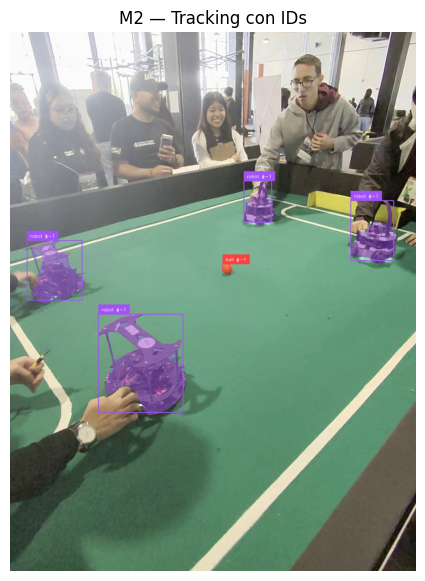

In [7]:
img = cv2.imread(str(TRACKING_IMG))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 7))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("M2 — Tracking con IDs")
plt.show()

Revisar CSV de trayectorias

In [8]:
df = pd.read_csv(OUTPUT_CSV)

print("Filas generadas:", len(df))
display(df.head(20))

if len(df) > 0:
    print("IDs únicos:", sorted(df["tracker_id"].unique().tolist()))
    print("Clases detectadas:", df["class_name"].value_counts().to_dict())
else:
    print("El CSV está vacío. Revisa si SAM 3 detectó objetos en estos frames.")

Filas generadas: 113


,frame,tracker_id,class_id,class_name,x_center,y_center,width,height,confidence
0,0,-1,0,robot,438.078674,1111.723389,282.725067,330.279907,0.956474
1,0,-1,0,robot,829.882263,569.184021,93.062622,139.120575,0.930487
2,0,-1,0,robot,1213.648193,665.858582,144.016602,201.011108,0.913582
3,0,-1,0,robot,149.581924,799.196472,184.182129,200.215210,0.873958
4,0,-1,1,ball,724.134460,790.914062,22.791748,25.577637,0.887006
5,1,0,0,robot,433.968079,1111.618042,282.827240,329.603943,0.960364
6,1,1,0,robot,829.909546,568.816284,93.426453,139.393433,0.929139
7,1,2,0,robot,1213.627930,665.119629,144.007324,202.096313,0.926639
8,1,3,0,robot,146.597137,801.518677,187.391342,201.948853,0.905709
9,1,4,1,ball,723.897827,790.807556,22.819031,25.817627,0.887306


IDs únicos: [-1, 0, 1, 2, 3, 4]
Clases detectadas: {'robot': 85, 'ball': 28}


Crear muestra ligera para GitHub

In [9]:
if len(df) > 0:
    df.head(50).to_csv(SAMPLE_CSV, index=False)
    print("Muestra ligera guardada en:", SAMPLE_CSV)
else:
    print("No se creó sample_tracks.csv porque no hubo detecciones.")

Muestra ligera guardada en: c:\Users\diego\OneDrive\Documentos\GitHub\Proyecto-VisionPorComputadora\docs\assets\m2\sample_tracks.csv


## Conclusiones M2

Este notebook valida que:

- El video se puede leer frame por frame.
- SAM 3 genera detecciones para los prompts definidos.
- ByteTrack asigna IDs a los objetos detectados.
- Las trayectorias se exportan a CSV.
- Se generan imágenes ligeras de evidencia para el README.

Limitaciones observadas:

- Los IDs pueden cambiar si un robot se oculta.
- El balón puede perderse si aparece pequeño o borroso.
- Los prompts de texto pueden confundir robots cercanos o partes del campo.

Estas limitaciones se documentan para continuar en M3 con Ghost Replay, eventos y visualizaciones tácticas.